<a href="https://colab.research.google.com/github/juanepstein99/DI_Bootcamp/blob/main/Week14/Day6/DailyChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import statsmodels.stats.api as sms
from scipy.stats import (ttest_1samp, shapiro, levene, ttest_ind, mannwhitneyu,
                         pearsonr, spearmanr, kendalltau, f_oneway, kruskal)
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multicomp import MultiComparison


In [2]:
from google.colab import files
import zipfile
from pathlib import Path

uploaded=files.upload()
zip_name=list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name,'r') as z:
    z.extractall('/content/data')
csv_path=list(Path('/content/data').rglob('*.csv'))[0]
df=pd.read_csv(csv_path)
print(df.head())

Saving AB_Test_Results.zip to AB_Test_Results.zip
   USER_ID VARIANT_NAME  REVENUE
0      737      variant      0.0
1     2423      control      0.0
2     9411      control      0.0
3     7311      control      0.0
4     6174      variant      0.0


# Data Understanding

In [3]:
print(df.info())
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescriptive statistics:")
display(df.describe())
print("\nVariant counts:")
print(df['VARIANT_NAME'].value_counts())
print("\nUnique users:", df['USER_ID'].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   USER_ID       10000 non-null  int64  
 1   VARIANT_NAME  10000 non-null  object 
 2   REVENUE       10000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 234.5+ KB
None

Columns: ['USER_ID', 'VARIANT_NAME', 'REVENUE']

Missing values:
USER_ID         0
VARIANT_NAME    0
REVENUE         0
dtype: int64

Descriptive statistics:


,USER_ID,REVENUE
count,10000.000000,10000.000000
mean,4981.080200,0.099447
std,2890.590115,2.318529
min,2.000000,0.000000
25%,2468.750000,0.000000
50%,4962.000000,0.000000
75%,7511.500000,0.000000
max,10000.000000,196.010000



Variant counts:
VARIANT_NAME
variant    5016
control    4984
Name: count, dtype: int64

Unique users: 6324


# Average Revenue by VARIANT_NAME

In [4]:
avg_revenue=df.groupby('VARIANT_NAME')['REVENUE'].mean()
print(avg_revenue)
display(avg_revenue.to_frame('Average Revenue'))

VARIANT_NAME
control    0.129013
variant    0.070070
Name: REVENUE, dtype: float64


,Average Revenue
VARIANT_NAME,
control,0.129013
variant,0.070070


What if H0: M1 = M2 ?
What about H1: M1 1= M2 ?

# Assumptions Control:
*# 1- Normality Assumptions*
*# 2- Homogeneity of Variances Assumption*

In [5]:
control=df[df['VARIANT_NAME']=='control']['REVENUE']
variant=df[df['VARIANT_NAME']=='variant']['REVENUE']

stat_c,p_c=shapiro(control)
stat_v,p_v=shapiro(variant)

print(f'Control p-value: {p_c:.4f}')
print(f'Variant p-value: {p_v:.4f}')

if p_c>0.05 and p_v>0.05:
    print('The data appear normally distributed.')
else:
    print('The data are NOT normally distributed. Reject H0.')

Control p-value: 0.0000
Variant p-value: 0.0000
The data are NOT normally distributed. Reject H0.


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5016.
  res = hypotest_fun_out(*samples, **kwds)


In [6]:
stat,p=levene(control,variant)
print(f'Levene p-value: {p:.4f}')
if p>0.05:
    print('Equal variances can be assumed.')
else:
    print('Variances are significantly different.')

Levene p-value: 0.2037
Equal variances can be assumed.


# Non-Parametric Test (mannwhitneyu Test)

In [7]:
stat,p=mannwhitneyu(control,variant,alternative='two-sided')
print(f'Mann-Whitney U statistic: {stat}')
print(f'p-value: {p:.4f}')
if p<0.05:
    print('Reject H0: significant difference between groups.')
else:
    print('Fail to reject H0: no significant difference between groups.')

Mann-Whitney U statistic: 12521564.0
p-value: 0.4783
Fail to reject H0: no significant difference between groups.


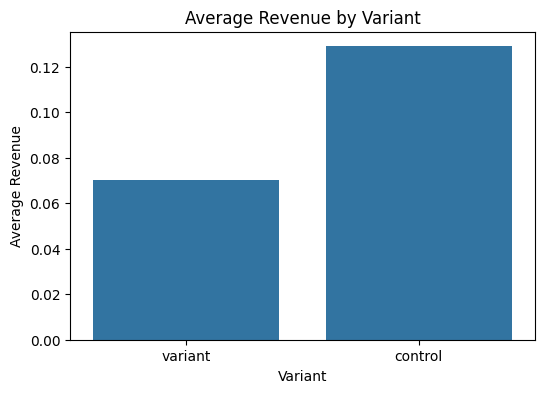

In [8]:
plt.figure(figsize=(6,4))
sns.barplot(data=df,x='VARIANT_NAME',y='REVENUE',estimator='mean',errorbar=None)
plt.title('Average Revenue by Variant')
plt.xlabel('Variant')
plt.ylabel('Average Revenue')
plt.show()